In [18]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier

# Utils

In [3]:
# Loss Ratio Calculation (Коэффициент выплат)
def loss_ratio(claims, premiums):
    total_claims = claims.sum()
    total_premium = premiums.sum()
    return (total_claims / total_premium) if total_premium != 0 else 0

class Metrics:    
    def __init__(self, data, new_premiums, lower = 0, upper = 3):
        self.old_premiums = data['premium']
        self.old_premiums_wo_term = data['premium_wo_term']
        self.claims_amount = data['claim_amount']
        self.claims_cnt = data['claim_cnt']
        self.premiums_percent = self.old_premiums_wo_term / self.old_premiums

        self.new_premiums = new_premiums
        self.new_premiums.clip(self.old_premiums * lower, self.old_premiums * upper, inplace=True) 
        self.new_premiums_wo_term = self.new_premiums * self.premiums_percent

        self.old_loss = loss_ratio(self.claims_amount, self.old_premiums_wo_term)
        self.new_loss = loss_ratio(self.claims_amount, self.new_premiums_wo_term)

        increased = self.new_premiums > self.old_premiums
        not_increased = ~increased
        have_claims = self.claims_cnt > 0

        self.n_total = len(self.old_premiums)
        self.n_increased = increased.sum()
        self.n_not_increased = not_increased.sum()
        
        false_increase = increased & (~have_claims)
        false_decrease = (~increased) & have_claims
        self.n_false_inc = false_increase.sum()
        self.n_false_dec = false_decrease.sum()

    def __str__(self):
        return f"""
Old loss ratio: {self.old_loss * 100:.2f}%
New loss ratio: {self.new_loss * 100:.2f}%
Increased: {self.n_increased / self.n_total * 100:.2f}%
Falsely increased: {self.n_false_inc / self.n_increased * 100 if self.n_increased > 0 else 0:.2f}%
Falsely decreased: {self.n_false_dec / self.n_not_increased * 100 if self.n_not_increased > 0 else 0:.2f}%
"""

# Loading data

In [4]:
def load_dataset(path, nrows = None, is_test = False):
    unused_columns = [
        "unique_id", 
        "is_individual_person", 
        "is_individual_person_name"
    ]
    
    df = pd.read_csv(
        path, 
        nrows=nrows,  
        usecols = lambda col: col not in unused_columns,
        dtype={
            'bonus_malus': 'str',
            'car_year': 'str',
            'ownerkato': 'Int64', 
            'ownerkato_short': 'Int64'
        },
        parse_dates=['operation_date'],
        date_format="%Y-%m-%d",
    )

    if not is_test:
        df['claim_amount'] = df['claim_amount'].fillna(0)
        df['claim_cnt'] = df['claim_cnt'].fillna(0)

    policy_agg = {
        'premium': 'first',
        'premium_wo_term': 'first',
        'is_residence': 'first',
        'is_residence_name': 'first',
        'operation_date': 'first',
        'insurer_iin': 'first',
        'region_id': 'first',
        'region_name': 'first',
        'ownerkato': 'first',
        'ownerkato_short': 'first',
    
        "driver_iin": "nunique",
        "car_number": "nunique",

        # Drivers
        "bonus_malus": "mean",
        "experience_year": "mean",
        'SCORE_8_1': "mean",
        'SCORE_8_2': "mean",
        'SCORE_8_3': "mean",
        
        # Cars
        # "car_year": "mean",
        "engine_power": "mean",
        "engine_volume": "mean",
    }

    df["bonus_malus"] = (
        df["bonus_malus"]
        .replace("M", -1)
        .pipe(pd.to_numeric, errors="coerce")
        .astype("Int64")
    )

    if not is_test:
        policy_agg.update({
            'claim_amount': 'first',
            'claim_cnt': 'first',
            'is_claim': 'first',
        })

    # Per policy table
    policy = df.groupby('contract_number').agg(policy_agg).reset_index()
    policy.rename(columns={
        "driver_iin": "driver_cnt",
        "car_number": "car_cnt"
    }, inplace=True)
    
    # New features
    policy['premium_percent'] = policy['premium_wo_term'] / policy['premium']

    if not is_test:
        policy['severity'] = np.where(
            policy["claim_cnt"] > 0,
            policy["claim_amount"] / policy["claim_cnt"],
            0
        )
    
    return df, policy

In [5]:
TRAIN_FILE = 'dataset/train.csv'
TEST_FILE = 'dataset/test.csv'
N_TRAIN_SAMPLES = None
N_TEST_SAMPLES = None

train, train_policy = load_dataset(TRAIN_FILE, nrows=N_TRAIN_SAMPLES)
test, test_policy = load_dataset(TEST_FILE, nrows=N_TEST_SAMPLES, is_test=True)

In [6]:
for column in train.columns:
    dtype = train[column].dtype
    na_cnt = train[column].isna().sum()
    print(f"{column:<20} {str(dtype):<12} {na_cnt}")

contract_number      str          0
premium              float64      0
premium_wo_term      float64      0
operation_date       datetime64[us] 0
claim_amount         float64      0
claim_cnt            float64      0
is_claim             int64        0
insurer_iin          str          354
driver_iin           str          1055
is_residence         int64        0
is_residence_name    str          0
region_id            int64        0
region_name          str          0
bonus_malus          Int64        8
age_experience_id    int64        0
age_experience_name  str          0
experience_year      int64        0
vehicle_type_id      int64        0
vehicle_type_name    str          0
car_age              str          0
ownerkato            Int64        65495
ownerkato_short      Int64        65495
model                str          88
mark                 str          679
car_number           str          0
car_year             str          0
engine_volume        float64      1103
engine_

In [7]:
# score_cols = tdf['raw'].filter(regex='^SCORE').columns

# agg_dict = {
#     'bonus_malus': 'first',
#     'age_experience_id': 'first',
#     'age_experience_name': 'first',
#     'experience_year': 'first',
#     'car_number': 'nunique',
# }

# # add SCORE columns aggregation
# agg_dict.update({col: 'first' for col in score_cols})

# tdf['policy+driver'] = (
#     tdf['raw']
#         .groupby(['contract_number', 'driver_iin'])
#         .agg(agg_dict)
#         .reset_index()
# )
# ddf = tdf['policy+driver']

# Data analyze

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

pdf = train_policy

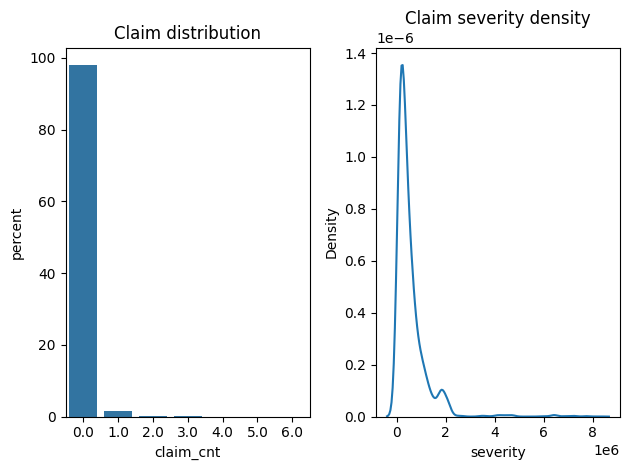

In [12]:
fig, ax = plt.subplots(1, 2)
sns.countplot(pdf, x='claim_cnt', stat='percent', ax=ax[0])
ax[0].set_title("Claim distribution")
sns.kdeplot(pdf[pdf['severity'] > 0], x="severity", ax=ax[1])
ax[1].set_title("Claim severity density")

plt.tight_layout()
plt.show()

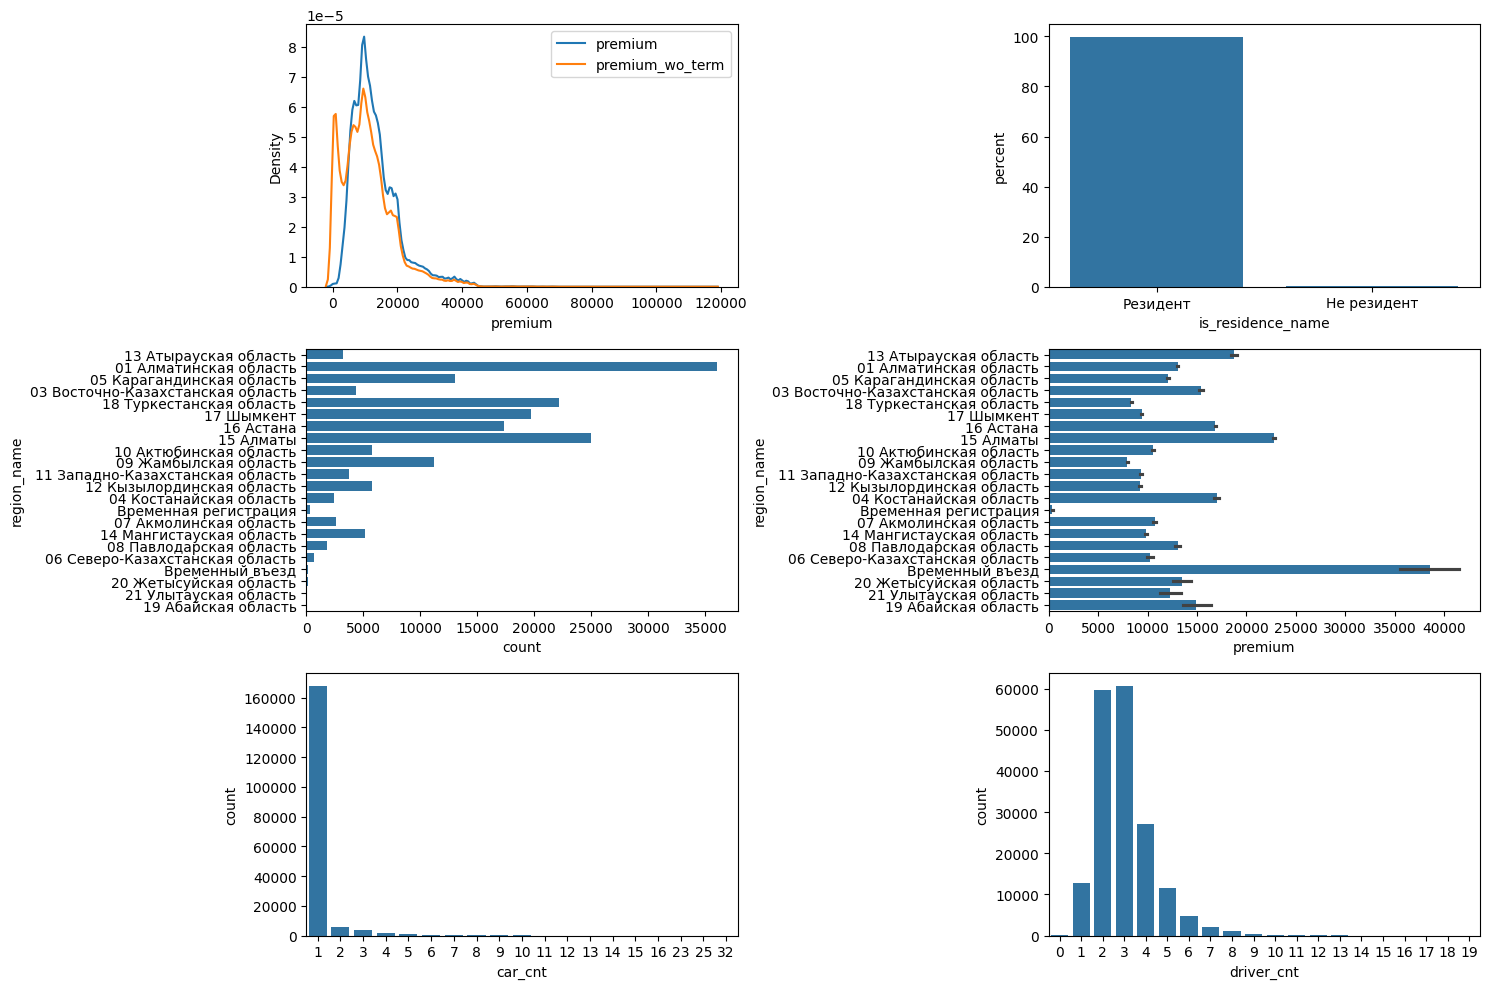

In [13]:
fig, ax = plt.subplots(3, 2, figsize=(15, 10))
sns.kdeplot(data=pdf, x="premium", ax=ax[0,0], label="premium")
sns.kdeplot(data=pdf, x="premium_wo_term", ax=ax[0,0], label="premium_wo_term")
ax[0,0].legend()

sns.countplot(data=pdf, x='is_residence_name', stat='percent', ax=ax[0,1])
sns.countplot(data=pdf, y='region_name', ax=ax[1,0])
sns.barplot(data=pdf, y='region_name', x='premium', ax=ax[1,1])

sns.countplot(data=pdf, x='driver_cnt', ax=ax[2,1])
sns.countplot(data=pdf, x='car_cnt', ax=ax[2,0])

plt.tight_layout()
plt.show()

# Models

In [14]:
class RegressionModel:
    def __init__(self, target_loss_ratio=0.7):
        self.target_loss_ratio = target_loss_ratio
        
        self.num_features = [
            "experience_year",
            "bonus_malus",
            "engine_power",
            "engine_volume",
            "driver_cnt",
            "car_cnt",
            "SCORE_8_1",
            "SCORE_8_2",
            "SCORE_8_3",
        ]

        self.cat_features = ["region_id"]

        preprocessor = ColumnTransformer(
            transformers=[
                ("num", StandardScaler(), self.num_features),
                ("cat", OneHotEncoder(handle_unknown="ignore"), self.cat_features),
            ]
        )
        
        self.pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=67))
        ])

    def fit(self, data):
        self.old_premiums_wo_term = data['premium_wo_term']
        self.claims_amount = data['claim_amount']
        
        X = self._select_data(data)
        y = data["is_claim"]
        
        X_train, X_valid, y_train, y_valid = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        self.pipeline.fit(X_train, y_train)

        proba = self.pipeline.predict_proba(X)[:,1]
        self.p_mean = proba.mean()
        self.alpha = self._search_alpha(proba)

    def predict_proba(self, data):
        X = self._select_data(data)
        return self.pipeline.predict_proba(X)[:,1]

    def predict_premiums(self, old_premiums, proba):
        beta = self._compute_beta(self.alpha, proba)
        return old_premiums * beta

    def _select_data(self, data):
        X = data[self.num_features + self.cat_features]
        X = X.fillna(0)
        return X
    
    def _compute_beta(self, alpha, proba, lower=0.0, upper=3.0):
        beta = 1.0 + alpha * (proba - self.p_mean)
        return np.clip(beta, lower, upper) 
    
    def _compute_loss_ratio_for_beta(self, beta):
        new_premiums = self.old_premiums_wo_term * beta
        return loss_ratio(self.claims_amount, new_premiums)

    def _search_alpha(self, proba, a_low=-50.0, a_high=200.0, iters=60):
        for _ in range(iters):
            a_mid = 0.5 * (a_low + a_high)
            beta = self._compute_beta(a_mid, proba)
            lr_mid = self._compute_loss_ratio_for_beta(beta)
            if lr_mid > self.target_loss_ratio:
                a_low = a_mid
            else:
                a_high = a_mid

        return 0.5 * (a_low + a_high)

In [30]:
class CatBoostModel:
    def __init__(self, target_loss_ratio=0.7, verbose=None):
        self.target_loss_ratio = target_loss_ratio
        
        self.num_features = [
            "experience_year",
            "bonus_malus",
            "engine_power",
            "engine_volume",
            "driver_cnt",
            "car_cnt",
            "SCORE_8_1",
            "SCORE_8_2",
            "SCORE_8_3",
        ]

        self.cat_features = ["region_id"]
        
        self.pipeline = CatBoostClassifier(
            iterations=5000, 
            auto_class_weights="Balanced",
            task_type="GPU",
            devices='0',
            random_state=67, 
            verbose=verbose
        )

    def fit(self, data):
        self.old_premiums_wo_term = data['premium_wo_term']
        self.claims_amount = data['claim_amount']
        
        X = self._select_data(data)
        y = data["is_claim"]
        
        X_train, X_valid, y_train, y_valid = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        self.pipeline.fit(X_train, y_train)

        proba = self.pipeline.predict_proba(X)[:,1]
        self.p_mean = proba.mean()
        self.alpha = self._search_alpha(proba)

    def predict_proba(self, data):
        X = self._select_data(data)
        return self.pipeline.predict_proba(X)[:,1]

    def predict_premiums(self, old_premiums, proba):
        beta = self._compute_beta(self.alpha, proba)
        return old_premiums * beta

    def _select_data(self, data):
        X = data[self.num_features + self.cat_features]
        X = X.fillna(0)
        return X
    
    def _compute_beta(self, alpha, proba, lower=0.0, upper=3.0):
        beta = 1.0 + alpha * (proba - self.p_mean)
        return np.clip(beta, lower, upper) 
    
    def _compute_loss_ratio_for_beta(self, beta):
        new_premiums = self.old_premiums_wo_term * beta
        return loss_ratio(self.claims_amount, new_premiums)

    def _search_alpha(self, proba, a_low=-50.0, a_high=200.0, iters=60):
        for _ in range(iters):
            a_mid = 0.5 * (a_low + a_high)
            beta = self._compute_beta(a_mid, proba)
            lr_mid = self._compute_loss_ratio_for_beta(beta)
            if lr_mid > self.target_loss_ratio:
                a_low = a_mid
            else:
                a_high = a_mid

        return 0.5 * (a_low + a_high)

In [20]:
# Training
reg_model = RegressionModel()
reg_model.fit(train_policy)
train_proba = reg_model.predict_proba(train_policy)
new_train_premiums = reg_model.predict_premiums(train_policy['premium'], train_proba)
metrics = Metrics(train_policy, new_train_premiums)
print(metrics)

# Testing
test_proba = reg_model.predict_proba(test_policy)
new_premiums = reg_model.predict_premiums(test_policy['premium'], test_proba)
results = pd.DataFrame({
    "contract_number": test_policy["contract_number"],
    "new_premium": new_premiums,
    "claim_probability": test_proba
})
print(f"Test increased: {(results["new_premium"] > test_policy["premium"]).sum() / test_policy["premium"].count() * 100:.2f}%")

# Save results
results.to_csv("dataset/Ratio_et_Actio_test_results.csv", index=False)


Old loss ratio: 123.34%
New loss ratio: 71.55%
Increased: 47.13%
Falsely increased: 97.04%
Falsely decreased: 1.10%

Test increased: 49.24%


In [31]:
# Training
reg_model = CatBoostModel(verbose=False)
reg_model.fit(train_policy)
train_proba = reg_model.predict_proba(train_policy)
new_train_premiums = reg_model.predict_premiums(train_policy['premium'], train_proba)
metrics = Metrics(train_policy, new_train_premiums)
print(metrics)

# Testing
test_proba = reg_model.predict_proba(test_policy)
new_premiums = reg_model.predict_premiums(test_policy['premium'], test_proba)
results = pd.DataFrame({
    "contract_number": test_policy["contract_number"],
    "new_premium": new_premiums,
    "claim_probability": test_proba
})
print(f"Test increased: {(results["new_premium"] > test_policy["premium"]).sum() / test_policy["premium"].count() * 100:.2f}%")

# Save results
results.to_csv("dataset/Ratio_et_Actio_test_results.csv", index=False)


Old loss ratio: 123.34%
New loss ratio: 70.00%
Increased: 50.84%
Falsely increased: 96.43%
Falsely decreased: 0.34%

Test increased: 40.19%
